In [138]:
import ratinabox
from ratinabox.Agent import Agent
from ratinabox.Neurons import PlaceCells
from ratinabox.contribs.NeuralNetworkNeurons import NeuralNetworkNeurons #for the Actor and Critic
from ratinabox.contribs.TaskEnvironment import (SpatialGoalEnvironment, SpatialGoal, Reward)

#misc
import torch 
import numpy as np 
from gymnasium.spaces import Box
from tqdm import tqdm
import time
import random
import seaborn as sns
import pandas as pd
from typing import List, Union, Optional, Tuple
import pickle
import os

from plotting_utils import *
from base_actor_critic import *
from training_utils import *

In [139]:
#TASK CONSTANTS
DT = 0.1 # Time step
T_TIMEOUT = 15 # Time out
GOAL_POS = np.array([0.5, 0.5]) # Goal position
WALL = None
# WALL = [[0.8, 0.0], [0.8, 0.8]]
GOAL_RADIUS = 0.1
REWARD = 1 # Reward
REWARD_DURATION = 1 # Reward duration

#LEARNING CONSTANTS
TAU = 5 # Discount time horizon
TAU_E = 5 # Eligibility trace time horizon
ETA = 0.01 # Learning rate 
N_EPISODES = 1 # Number of episodes
L2 = 0.000 # L2 regularization


In [140]:
def set_seed(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    torch.use_deterministic_algorithms(True)

In [141]:
def create_experiment(
    dt=0.1,
    t_timeout=15,
    input_min=-1.0,
    input_max=1.0,
    goal_pos=np.array([0.9, 0.9]),
    goal_radius=0.1,
    reward_val=1,
    reward_duration=1,
    wall=None,
    n_placecells=50,
    fta_eta=0.1,
    eta = 0.01,
    l2=0.0,
    tau=5,
    tau_e=5,
    actor_fta_post=[2],
    critic_fta_post=[1],
):
    """Returns a fresh environment, agent, place cells, actor, critic"""
    
    # --- Environment ---
    env = SpatialGoalEnvironment(dt=dt, teleport_on_reset=True, episode_terminate_delay=reward_duration)
    env.exploration_strength = 0
    if wall is not None:
        env.add_wall(wall)
    
    # Reward and goal
    reward = Reward(reward_val, decay="none", expire_clock=reward_duration, dt=dt)
    goals = [SpatialGoal(env, pos=goal_pos, goal_radius=goal_radius, reward=reward)]
    env.goal_cache.reset_goals = goals
    
    # --- Agent ---
    ag = Agent(env, params={'dt': dt})
    env.add_agents(ag)
    
    # --- Place Cells ---
    placecells = PlaceCells(ag, params={'n': n_placecells})
    
    # --- Networks ---
    # actorNN = VxVyGaussianFTA(n_in=placecells.n, post_fta=actor_fta_post)
    actorNN = VxVyGaussianMLP(n_in=placecells.n) #add seed
    criticNN = FTANetwork(n_in=placecells.n, input_min=input_min, input_max=input_max, post_fta=critic_fta_post, eta=fta_eta)
    
    # --- Actor ---
    default_params_actor = {
        "tau": tau,
        "tau_z": tau_e,
        "input_layers": [placecells],
        "NeuralNetworkModule": actorNN,
        "optimizer": lambda params: torch.optim.SGD(params, lr=eta, maximize=True, weight_decay=l2),
        "eligibility_traces": True,
    }
    actor = Actor(ag, params=default_params_actor)
    actor.colormap = "PiYG"
    
    # --- Critic ---
    default_params_critic = {
        "tau": tau,
        "tau_z": tau_e,
        "input_layers": [placecells],
        "NeuralNetworkModule": criticNN,
        "optimizer": lambda params: torch.optim.SGD(params, lr=eta, maximize=True, weight_decay=l2),
        "eligibility_traces": True,
    }
    critic = Critic(ag, params=default_params_critic)
    
    return env, ag, placecells, actor, critic

In [142]:
def plot_rate_maps(env, ag,actor, critic,reward = False, trajectory=False):
    if reward:
        fig, ax = plot_reward_history(env)
    
    fig, ax = critic.plot_rate_map(); fig.suptitle("Value function (before learning)")
    fig, ax = actor.plot_rate_map(zero_center=True); fig.suptitle("Policy (before learning)"); ax[0].set_title("Vx"); ax[1].set_title("Vy")

    if trajectory:
        fig, ax = ag.plot_trajectory(color="changing",t_start=env.episodes['start'][0],t_end=env.episodes['start'][0]); display_reward_patch(fig,ax, reward_pos=GOAL_POS, reward_radius=0.1)

In [143]:
def find_fta_module(net: torch.nn.Module):
    '''Find FTA layer in a network and print the type of each module as it searches'''
    for m in net.modules():
        #print(type(m))
        if isinstance(m, FTA):
            return m
    raise ValueError("No FTA module found in the network.")

In [168]:
def count_elements_above_threshold(all_episode_bins, episode, time_step, threshold, num_bins):
    counts = np.zeros(num_bins)
    for i in range(len(all_episode_bins[episode][time_step])):  # iterate over inner lists
        for b in range(num_bins):  # iterate over positions
            if all_episode_bins[episode][time_step][i][b] > threshold:
                counts[b] += 1
    return counts

In [ ]:
def create_fta_hook(fta, ag, env, bins, thres=0.1):
    fta_sparsity = []
    states = []
    time_steps = []
    fta_bins_sparsity = []
    fta_bins = []
    all_out_arrays = []
    

    def sparsity_function(fta_arr):
        return 1 - (np.sum(fta_arr[fta_arr > thres]) / fta_arr.size)

    def hook_fn(module, inputs, output):
        out_arr = output.detach().cpu().numpy().flatten()
        # print(f"FTA output: {out_arr}, shape: {out_arr.shape}")
        fta_b = np.array_split(out_arr, bins)
        # print(f"FTA bins: {fta_b} length: {len(fta_b)}")
        fta_sparse_bins = [sparsity_function(b) for b in fta_b]
        fta_sparsity.append(sparsity_function(out_arr))
        states.append(np.copy(ag.pos))  # or placecells.get_state()
        time_steps.append(env.t)
        fta_bins_sparsity.append(fta_sparse_bins)
        fta_bins.append(fta_b)
        all_out_arrays.append(out_arr)


    return hook_fn, fta_sparsity, states, time_steps,fta_bins, fta_bins_sparsity, all_out_arrays


In [ ]:
def run_multiple_episodes_with_fta(
    n_episodes,
    env,
    ag,
    actor,
    critic,
    placecells,
    fta,
    num_bins,
    time_limit=T_TIMEOUT
):
    """
    Runs multiple episodes, records FTA sparsity at each timestep.

    Returns:
        all_episode_sparsity: list of lists of sparsity values (one per episode)
        all_episode_time: list of lists of time steps (one per episode)
    """
    all_episode_sparsity = []
    all_episode_time = []
    all_episodes_state = []
    all_episode_bins_sparsity = []
    all_episode_bins = []
    all_count_bins = []

    try: 
        for i in (pbar := tqdm(range(n_episodes), desc = "")):
            # Reset environment and agent
            env.reset()
            # ag.reset()  # Uncomment if your agent has a reset method

            # Create new FTA hook for this episode
            hook_fn, fta_sparsity, fta_states, fta_times, fta_bins, fta_bins_sparsity, all_out_arrays = create_fta_hook(fta, ag, env, bins=num_bins)
            handle = fta.register_forward_hook(hook_fn)

            # Run one episode
            run_episode(env, ag, actor, critic, state_cells=[placecells], time_limit=time_limit, seed=i)

            # Remove hook
            handle.remove()

            # Store episode data
            all_episode_sparsity.append(fta_sparsity)
            all_episode_time.append(fta_times)
            all_episodes_state.append(fta_states)
            all_episode_bins_sparsity.append(fta_bins_sparsity)
            all_episode_bins.append(fta_bins)
            
            # success_frac = np.mean(np.array(env.episodes['meta_info'][-100:]) == "completed")
            episode_time = np.mean(env.episodes['duration'][-100:])
            # pbar.set_description(f"<success fraction>: {success_frac:.2f}, <episode time> {episode_time:.1f}")
            # if success_frac > 0.99 and i > 10: break
    except KeyboardInterrupt:
        print("Interrupted by user")

    
    return all_episode_sparsity, all_episode_time, all_episodes_state,all_episode_bins, all_episode_bins_sparsity, all_out_arrays

In [147]:
def plot_sparsity_over_episodes(all_episode_sparsity, all_episode_time):
    n = len(all_episode_sparsity)  

    plt.figure(figsize=(6,4))

    for i in range(n):
        plt.plot(all_episode_time[i], all_episode_sparsity[i], label=f"Episode {i+1}")

    plt.xlabel("Time step")
    plt.ylabel("FTA sparsity")
    plt.title("FTA sparsity across episodes")
    plt.legend()
    plt.show()

In [148]:
def plot_sparsity_state_time_continuous(sparsity,times,states):

    # flatten episodes
    # sparsity = np.concatenate(all_episode_sparsity)
    # times = np.concatenate(all_episode_time)
    # states = np.concatenate(all_episode_state)

    states = np.array(states)

    # choose one continuous state variable
    state_values = states[:,0]   # x coordinate (continuous)

    plt.figure(figsize=(8,5))

    sc = plt.scatter(
        times,
        state_values,
        c=sparsity,
        cmap="viridis",
        s=20
    )

    plt.ylabel("State (x position)")
    plt.xlabel("Time")
    plt.title("FTA Sparsity vs State and Time")

    plt.colorbar(sc, label="Sparsity")

    plt.show()

In [149]:
def plot_spatiotemporal_hist_grid(all_episode_bins_sparsity, all_episode_time, all_episodes_state, 
                                 episode_idx=0, t_bins=4, s_bins=3):
    # 1. Prepare Data
    bins_data = np.array(all_episode_bins_sparsity[episode_idx]) # (timesteps, 10_fta_bins)
    times = np.array(all_episode_time[episode_idx])
    states = np.array(all_episodes_state[episode_idx])[:, 0] # Using X-position as State
    
    # 2. Define Bin Edges
    t_edges = np.linspace(times.min(), times.max(), t_bins + 1)
    s_edges = np.linspace(states.min(), states.max(), s_bins + 1)
    
    # 3. Create Figure
    fig, axes = plt.subplots(s_bins, t_bins, figsize=(t_bins * 3, s_bins * 2.5), 
                             sharex=True, sharey=True)
    
    # We want State to increase downwards to match your image arrow
    # So we iterate through state bins in reverse or just map them accordingly
    for s_idx in range(s_bins):
        for t_idx in range(t_bins):
            ax = axes[s_idx, t_idx]
            
            # Find indices where data falls into this specific Space-Time tile
            mask = (times >= t_edges[t_idx]) & (times < t_edges[t_idx+1]) & \
                   (states >= s_edges[s_idx]) & (states < s_edges[s_idx+1])
            
            tile_data = bins_data[mask]
            
            if len(tile_data) > 0:
                # Flatten the FTA bins for this tile to see the overall sparsity distribution
                ax.hist(tile_data.flatten(), bins=15, color='cornflowerblue', edgecolor='white', alpha=0.8)
            else:
                ax.text(0.5, 0.5, 'No Data', ha='center', va='center', alpha=0.5)

            # Clean up axes
            ax.set_xticks([0, 0.5, 1])
            if s_idx == 0:
                ax.set_title(f"Time: {t_edges[t_idx]:.1f}s", fontsize=10)
            if t_idx == 0:
                ax.set_ylabel(f"State X: {s_edges[s_idx]:.1f}", fontsize=10)

    # Add the big Labels/Arrows style from your image
    fig.text(0.5, 0.95, 'TIME $\longrightarrow$', ha='center', va='center', fontsize=20, fontweight='bold')
    fig.text(0.02, 0.5, '$\longleftarrow$ STATE', ha='center', va='center', rotation='vertical', fontsize=20, fontweight='bold')

    plt.tight_layout(rect=[0.05, 0.05, 1, 0.92])
    plt.show()
    


<>:42: SyntaxWarning: invalid escape sequence '\l'
<>:43: SyntaxWarning: invalid escape sequence '\l'
<>:42: SyntaxWarning: invalid escape sequence '\l'
<>:43: SyntaxWarning: invalid escape sequence '\l'
/var/folders/bm/8wy6w6fs4rx3vlh4d8m7h7200000gn/T/ipykernel_10903/3100416349.py:42: SyntaxWarning: invalid escape sequence '\l'
  fig.text(0.5, 0.95, 'TIME $\longrightarrow$', ha='center', va='center', fontsize=20, fontweight='bold')
/var/folders/bm/8wy6w6fs4rx3vlh4d8m7h7200000gn/T/ipykernel_10903/3100416349.py:43: SyntaxWarning: invalid escape sequence '\l'
  fig.text(0.02, 0.5, '$\longleftarrow$ STATE', ha='center', va='center', rotation='vertical', fontsize=20, fontweight='bold')


In [150]:
def save_episode_data(filename,
                      all_episode_sparsity,
                      all_episode_time,
                      all_episode_state,
                      all_episode_bins_sparsity):
    
    data = {
        "all_episode_sparsity": all_episode_sparsity,
        "all_episode_time": all_episode_time,
        "all_episode_state": all_episode_state,
        "all_episode_bins_sparsity": all_episode_bins_sparsity
    }

    with open(filename, "wb") as f:
        pickle.dump(data, f)

    print(f"Data saved to {filename}")

In [ ]:
set_seed(42)

env, ag, placecells, actor, critic = create_experiment(dt=0.1, fta_eta=0.1, input_min=-1, input_max=1, t_timeout=15, goal_pos=GOAL_POS, goal_radius=GOAL_RADIUS, reward_val=REWARD, reward_duration=REWARD_DURATION, wall=WALL, n_placecells=50)
fta = find_fta_module(critic.NeuralNetworkModule)
all_episode_sparsity, all_episode_time, all_episodes_state, all_episode_bins, all_episode_bins_sparsity, all_out_arrays = run_multiple_episodes_with_fta(n_episodes=N_EPISODES, env=env, ag=ag, actor=actor, critic=critic, placecells=placecells, fta=fta, num_bins=20)




/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/ratinabox/utils.py:837: UserWarning: Cannot collect the default_params dictionaries, as Actor does not have the class attribute 'default_params' defined in its preamble. (Can be just an empty dictionary, i.e.: default_params = dict().)
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/ratinabox/utils.py:892: UserWarning: Cannot check the keys in the params dictionary, as <class 'base_actor_critic.Actor'> does not have a class attribute 'default_params' defined in its preamble. (Can be just an empty dictionary, i.e.: default_params = dict().)
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/ratinabox/utils.py:837: UserWarning: Cannot collect the default_params dictionaries, as Critic does not have the class attribute 'default_params' defined in its preamble. (Can be just an empty dictionary, i.e.: default_params = 

 fta_eta: 0.1, n_tilings: 1, n_tiles: 10


100%|██████████| 1/1 [00:00<00:00, 12.46it/s]


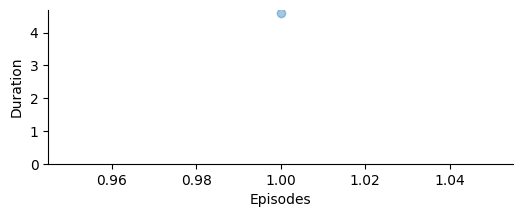

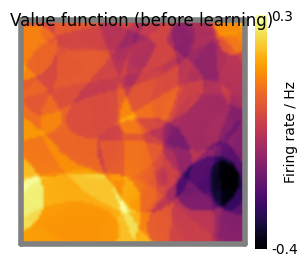

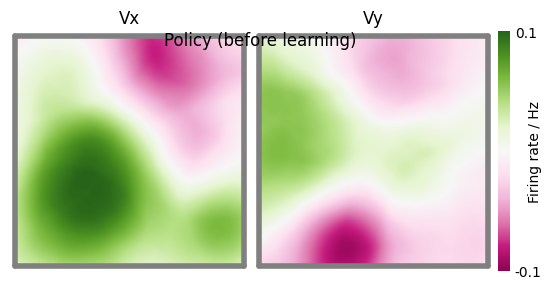

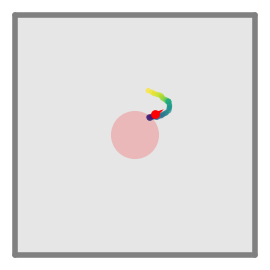

In [159]:
plot_rate_maps(env,ag,actor, critic,reward=True,trajectory=True)

In [167]:
print(len(all_episode_sparsity), len(all_episode_time), len(all_episodes_state), len(all_episode_bins_sparsity), len(all_episode_bins[0]), len(all_out_arrays[0]), len(all_count_bins))
print(env.t/env.dt) # time steps per episode
assert all(len(lst) == 20 for lst in all_episode_bins[0]), "Not all lists have length 20"
print(all_count_bins)


1 1 1 1 46 200 20
45.99999999999999
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


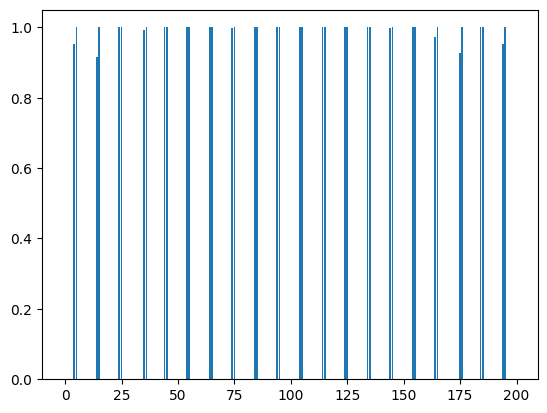

In [161]:
# All units of the last layer

x = np.arange(len(all_out_arrays[0]))

plt.bar(x, all_out_arrays[0])
plt.show()



In [163]:
threshold = 0.1
episode = 0
time_step = 45
num_bins = 10


plt.bar(np.arange(num_bins), all_count_bins[episode][time_step])
plt.xlabel("Bins")
plt.ylabel(f"Count")
# plt.title("Count of elements above threshold at each position")
plt.show()

IndexError: invalid index to scalar variable.

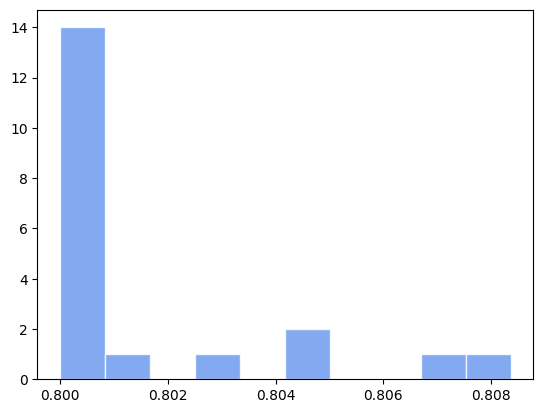

In [ ]:
# Histogram of sparsity values in the first bin across the episode

plt.hist(all_episode_bins_sparsity[0][0], color='cornflowerblue', edgecolor='white', alpha=0.8)
plt.show()